In [1]:
!pip install pandas_ta

In [2]:
import pandas as pd
import numpy as np
# import pandas_ta
import ta
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv( "C:/Users/DELL/Desktop/UOIT/capstone/AMZN_alpha_1min_2024-05_to_2025-05.csv")

In [4]:
 #Convert 'Timestamp' from object to datetime.
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

#check if it is  converted
print( "the data type of 'Timestap' in dataset is", df['Timestamp'].dtype)


the data type of 'Timestap' in dataset is datetime64[ns]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236744 entries, 0 to 236743
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Timestamp  236744 non-null  datetime64[ns]
 1   Open       236744 non-null  float64       
 2   High       236744 non-null  float64       
 3   Low        236744 non-null  float64       
 4   Close      236744 non-null  float64       
 5   Volume     236744 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 10.8 MB


In [6]:
# Define regular trading hours
import datetime
market_open = datetime.time(9, 30)
market_close = datetime.time(16, 0)

# Keep only rows within regular trading hours
df = df[
    (df['Timestamp'].dt.time >= market_open) & 
    (df['Timestamp'].dt.time <= market_close)
].copy()


In [7]:
print(f" First {df.head(1)}")
print(f" Last {df.tail(1)}")

 First               Timestamp     Open   High     Low   Close   Volume
330 2024-05-01 09:30:00  181.635  182.0  180.29  181.36  1786342
 Last                  Timestamp    Open    High    Low  Close    Volume
236504 2025-04-30 16:00:00  184.32  187.25  183.7  185.6  20316526


In [8]:
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#

In [9]:
# RCI_9
def rci(series, period=9):
    result = np.full(len(series), np.nan)
    for i in range(period-1, len(series)):
        price = series[i-period+1:i+1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1  # rank
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff**2)) / (period * (period**2 - 1))) * 100
        result[i] = rci_value
    return result

#  RCI (9 periods) !
df['RCI_9'] = rci(df['Close'], period=14)



# # 3. MACD
# macd = ta.trend.macd(df['Close'], window_slow=26, window_fast=12)
# macd_signal = ta.trend.macd_signal(df['Close'], window_slow=26, window_fast=12, window_sign=9)
# df['MACD'] = macd
# df['MACD_signal'] = macd_signal
# df['MACD_hist'] = macd - macd_signal


# # 7. Relative Strength Index (RSI)
# df['RSI'] = ta.momentum.rsi(df['Close'], window=7, fillna=True)
# # https://choiceindia.com/blog/best-rsi-setting-for-intraday


# 10. Williams %R !
df['WilliamsR'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'], lbp=14, fillna=True)
# https://trendspider.com/learning-center/introduction-to-williams-r-range/

# # 11. Percentage Price Oscillator (PPO) !
# df['PPO'] = ta.momentum.ppo(df['Close'], window_slow=26, window_fast=12, window_sign=9, fillna=True)
# # https://www.investopedia.com/terms/p/ppo.asp


# 13. Stochastic Oscillator
# Calculate %K
df['Stoch_K'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'], window=14, smooth_window=3, fillna=True)


# 15. Chaikin Money Flow (CMF) !
def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

df['CMF'] = chaikin_money_flow(df, window=20)
# https://help.stockdoctor.com.au/hc/en-us/articles/360000099635-Chaikin-Money-Flow


#--------------------Youssef Part-----------------------#
#--------------------Youssef Part-----------------------#
# PSAR ! 
df['PSAR'] = ta.trend.PSARIndicator(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    step=0.02,
    max_step=0.2
).psar()


# # Bollinger Bands parameters !
# bb_length = 20
# bb_std = 2

# # Calculate Bollinger Bands
# df['BB_Middle'] = df['Close'].rolling(window=bb_length).mean()
# df['BB_Std'] = df['Close'].rolling(window=bb_length).std()
# df['BB_Upper'] = df['BB_Middle'] + bb_std * df['BB_Std']
# df['BB_Lower'] = df['BB_Middle'] - bb_std * df['BB_Std']


# # SMA parameters !
# sma_length = 20
# df['SMA'] = df['Close'].rolling(window=sma_length).mean()


# Envelope parameters !
ma_length = 20
envelope_pct = 0.02
df['SMA_Envelope'] = df['Close'].rolling(window=ma_length).mean()
df['Upper_Envelope'] = df['SMA_Envelope'] * (1 + envelope_pct)
# df['Lower_Envelope'] = df['SMA_Envelope'] * (1 - envelope_pct)


# AO parameters !
# Calculate median price
df['Median_Price'] = (df['High'] + df['Low']) / 2
df['AO'] = df['Median_Price'].rolling(window=5).mean() - df['Median_Price'].rolling(window=34).mean()


# # CMO with 14-period !
# def cmo(series, window=14):
#     diff = series.diff()
#     up = diff.clip(lower=0).fillna(0)
#     down = -diff.clip(upper=0).fillna(0)
#     sum_up = up.rolling(window=window).sum()
#     sum_down = down.rolling(window=window).sum()
#     cmo_val = 100 * (sum_up - sum_down) / (sum_up + sum_down)
#     return cmo_val

# df['CMO'] = cmo(df['Close'], window=14)



# StdDev parameters !
std_length = 20

# Calculate SMA and StdDev over the period
# df['SMA_Std'] = df['Close'].rolling(window=std_length).mean()
df['STD_Std'] = df['Close'].rolling(window=std_length).std()


# Ichimoku !
ichimoku = ta.trend.IchimokuIndicator(
    high=df['High'],
    low=df['Low'],
    window1=9,    # Tenkan-sen
    window2=26,   # Kijun-sen
    window3=52,   # Senkou Span B
    visual=False  # If True, returns only lines for plotting
)

df['Tenkan_Sen'] = ichimoku.ichimoku_conversion_line()
df['Kijun_Sen'] = ichimoku.ichimoku_base_line()
df['Senkou_Span_A'] = ichimoku.ichimoku_a()
df['Senkou_Span_B'] = ichimoku.ichimoku_b()
df['Chikou_Span'] = df['Close'].shift(-26)



# ADX
adx_indicator = ta.trend.ADXIndicator(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    window=14,  # adx_length
    fillna=False
)
df['Plus_DI'] = adx_indicator.adx_pos()
df['Minus_DI'] = adx_indicator.adx_neg()
df['ADX'] = adx_indicator.adx()


# 14. Internal Bar Strength (IBS)
# df['IBS'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

# # Envelope 
# env_length = 20    # period
# env_dev = 0.02     # 2% band

# df['Envelope_SMA'] = df['Close'].rolling(window=env_length).mean()
# df['Envelope_Upper'] = df['Envelope_SMA'] * (1 + env_dev)

In [10]:
# drop NaN from both datasets
df = df.dropna().reset_index(drop=True)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp         0
Open              0
High              0
Low               0
Close             0
Volume            0
RCI_9             0
WilliamsR         0
Stoch_K           0
CMF               0
PSAR              0
SMA_Envelope      0
Upper_Envelope    0
Median_Price      0
AO                0
STD_Std           0
Tenkan_Sen        0
Kijun_Sen         0
Senkou_Span_A     0
Senkou_Span_B     0
Chikou_Span       0
Plus_DI           0
Minus_DI          0
ADX               0
dtype: int64


In [11]:
pd.set_option('display.max_columns', None)  # Show all columns in output
df.head(5)

,Timestamp,Open,High,Low,Close,Volume,RCI_9,WilliamsR,Stoch_K,CMF,PSAR,SMA_Envelope,Upper_Envelope,Median_Price,AO,STD_Std,Tenkan_Sen,Kijun_Sen,Senkou_Span_A,Senkou_Span_B,Chikou_Span,Plus_DI,Minus_DI,ADX
0,2024-05-01 10:03:00,180.990,181.0600,180.75,180.80,392729,50.329670,-96.621622,3.378378,0.025831,182.075373,181.28823,184.913995,180.9050,0.448574,0.299917,181.385,181.000,181.1925,180.245,180.015,14.300389,15.972601,7.997081
1,2024-05-01 10:04:00,180.800,181.2200,180.49,180.51,345166,79.340659,-98.850575,1.149425,-0.026657,181.995851,181.26923,184.894615,180.8550,0.352103,0.336303,181.255,181.000,181.1275,180.245,180.100,13.149997,17.552847,8.450161
2,2024-05-01 10:05:00,180.500,180.5814,180.13,180.19,370766,81.978022,-97.142857,2.857143,-0.137634,181.875383,181.21973,184.844125,180.3557,0.145262,0.414009,180.945,181.000,180.9725,180.245,180.060,12.481370,20.715428,9.618276
3,2024-05-01 10:06:00,180.185,180.5800,180.15,180.37,251475,83.296703,-88.571429,11.428571,-0.172999,181.700845,181.18086,184.804477,180.3650,-0.109326,0.455565,180.945,181.125,181.0350,180.245,180.070,11.862599,19.688450,10.702954
4,2024-05-01 10:07:00,180.370,180.6500,180.28,180.64,195393,80.659341,-73.437500,26.562500,-0.137448,181.543760,181.16536,184.788667,180.4650,-0.282414,0.468911,180.945,181.180,181.0625,180.245,180.100,12.172525,18.823701,11.471173


In [12]:
eng_features = ['RCI_9', 'WilliamsR', 'Stoch_K', 'CMF', 'PSAR',  'Upper_Envelope',  'Median_Price', 'AO',  'STD_Std', 'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span', 'Plus_DI', 'Minus_DI', 'ADX']

print("Number of eng_features are ", len(eng_features))
print(eng_features)

Number of eng_features are  17
['RCI_9', 'WilliamsR', 'Stoch_K', 'CMF', 'PSAR', 'Upper_Envelope', 'Median_Price', 'AO', 'STD_Std', 'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span', 'Plus_DI', 'Minus_DI', 'ADX']


In [13]:

# df = df.dropna().reset_index(drop=True)
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp         0
Open              0
High              0
Low               0
Close             0
Volume            0
RCI_9             0
WilliamsR         0
Stoch_K           0
CMF               0
PSAR              0
SMA_Envelope      0
Upper_Envelope    0
Median_Price      0
AO                0
STD_Std           0
Tenkan_Sen        0
Kijun_Sen         0
Senkou_Span_A     0
Senkou_Span_B     0
Chikou_Span       0
Plus_DI           0
Minus_DI          0
ADX               0
dtype: int64


In [14]:
#------------------Normalization------------------#
#------------------Normalization------------------#
#------------------Normalization------------------#


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[eng_features] = scaler.fit_transform(df[eng_features])

In [16]:
# Define the intrady next return (close-open)/open.
df['Return'] = (df['Close'].shift(-1) - df['Open'].shift(-1)) / df['Open'].shift(-1)

#create binary direction label (1 if up, 0 if down or flat)
df['Direction'] = (df['Return'] > 0).astype(int)
# df['Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [17]:
n = len(df)
train_end = int(0.60 * n)
validate_end = int(0.70 * n)  # 70%

df_train = df.iloc[:train_end].reset_index(drop=True)
df_validate = df.iloc[train_end:validate_end].reset_index(drop=True)
df_test  = df.iloc[validate_end:].reset_index(drop=True)

print(f"Train set: {df_train.shape}")
print(f"Validation set: {df_validate.shape}")
print(f"Test set: {df_test.shape}")


Train set: (58614, 26)
Validation set: (9769, 26)
Test set: (29308, 26)


In [18]:
# Target variable name
target = 'Direction'

# X/y for Train
X_train = df_train[eng_features].values   # eng_features have been defined previously at the cell of Feature Engineering
y_train = df_train[target].values

# X/y for Validation
X_validate = df_validate[eng_features].values
y_validate = df_validate[target].values

# X/y for Test
X_test = df_test[eng_features].values
y_test = df_test[target].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_validate: {X_validate.shape}, y_validate: {y_validate.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (58614, 17), y_train: (58614,)
X_validate: (9769, 17), y_validate: (9769,)
X_test: (29308, 17), y_test: (29308,)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# ANN 
model = Sequential()
model.add(Dense(17, activation='relu', input_shape=(len(eng_features),))) # number of neurons in input layer is the same as the number of technical indicators
for _ in range(7):  # hidden layers
    model.add(Dense(17, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary output

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy', 'mse'])


# # early stop
early_stop = EarlyStopping(
    monitor='val_accuracy',       
    patience=5,               # stop if no improvement after 5 epochs
    restore_best_weights=True # restores weights from best epoch
)

# train 
history = model.fit(
    X_train, y_train,
    epochs=32,
    batch_size=128,
    validation_data=(X_validate, y_validate),
    callbacks=[early_stop],
    verbose=2
)

# Evaluate on Test
test_loss, test_acc, test_mse = model.evaluate(X_test, y_test)


train_acc = history.history['accuracy'][-1] * 100
train_mse = history.history['mse'][-1]
val_acc = history.history['val_accuracy'][-1] * 100
val_mse = history.history['val_mse'][-1]

print(f"Train Accuracy: {train_acc:.2f}%, Train MSE: {train_mse:.4f}")
print(f"Test Accuracy: {test_acc:.2%}, Test MSE: {test_mse:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%, Validation MSE: {val_mse:.4f}")




Epoch 1/32


D:\Anaconda\envs\notebook-7.3.2\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


458/458 - 3s - 7ms/step - accuracy: 0.5042 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.5030 - val_loss: 0.6932 - val_mse: 0.2500
Epoch 2/32
458/458 - 1s - 2ms/step - accuracy: 0.5039 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.5032 - val_loss: 0.6931 - val_mse: 0.2500
Epoch 3/32
458/458 - 1s - 2ms/step - accuracy: 0.5044 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.5034 - val_loss: 0.6936 - val_mse: 0.2502
Epoch 4/32
458/458 - 1s - 2ms/step - accuracy: 0.5062 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.5089 - val_loss: 0.6929 - val_mse: 0.2499
Epoch 5/32
458/458 - 1s - 2ms/step - accuracy: 0.5035 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.5037 - val_loss: 0.6929 - val_mse: 0.2499
Epoch 6/32
458/458 - 1s - 2ms/step - accuracy: 0.5063 - loss: 0.6930 - mse: 0.2499 - val_accuracy: 0.5083 - val_loss: 0.6932 - val_mse: 0.2500
Epoch 7/32
458/458 - 1s - 2ms/step - accuracy: 0.5074 - loss: 0.6930 - mse: 0.2499 - val_accuracy: 0.5012 - val_loss: 0.6929 - val_mse: 0.2499
Epoch 8/32

In [20]:
#------------------- Tunner ----------------------#
#------------------- Tunner ----------------------#
#------------------- Tunner ----------------------#

In [22]:
#---------Return Calculation-----------#
#---------Return Calculation-----------#
#---------Return Calculation-----------#


In [37]:
fee_per_trade = 0.0004

# Predict probabilities or class labels on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)  # Binary prediction: 1=buy, 0=do nothing

df_test['Predicted'] = y_pred

# Returns on predicted trades 
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
trade_return_with_fee = trade_return - fee_per_trade

total_trade_return = trade_return.sum() 
total_trade_return_with_fee = trade_return_with_fee.sum()

num_trades = len(trade_return)
average_trade_return = trade_return.mean()
average_trade_return_with_fee = trade_return_with_fee.mean()

# Win Rate
win_trades = (trade_return > 0).sum()
winrate = win_trades / num_trades if num_trades > 0 else 0

win_trades_with_fee = (trade_return_with_fee > 0).sum()
winrate_with_fee = win_trades_with_fee / num_trades if num_trades > 0 else 0

# Average Daily Return
df_test['trading_Date'] = pd.to_datetime(df_test['Timestamp']).dt.date
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
trade_date_with_fee = trade_date.copy()
trade_date_with_fee['Return'] = trade_return_with_fee.values

daily_return = trade_date.groupby('trading_Date')['Return'].sum()
average_daily_return = daily_return.mean()

daily_return_with_fee = trade_date_with_fee.groupby('trading_Date')['Return'].sum()
average_daily_return_with_fee = daily_return_with_fee.mean()

# Cumulative Return 
cumulative_return = (np.prod(1 + trade_return) - 1) * 100  # as percent
cumulative_return_with_fee = (np.prod(1 + trade_return_with_fee) - 1) * 100

# Max Drawdown Calculation
cumulative = (1 + trade_return).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min() * 100  # as percent

cumulative_with_fee = (1 + trade_return_with_fee).cumprod()
running_max_with_fee = cumulative_with_fee.cummax()
drawdown_with_fee = (cumulative_with_fee - running_max_with_fee) / running_max_with_fee
max_drawdown_with_fee = drawdown_with_fee.min() * 100  # as percent

print("=== No Fee ===")
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.4f}")
print(f"Average daily return: {average_daily_return:.4f}")
print(f"Number of trades: {num_trades}")
print(f"Average return per trade: {average_trade_return:.4f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

print("\n=== With Fee ===")
print(f"Cumulative Return: {cumulative_return_with_fee:.2f}%")
print(f"Total Sum of Return: {total_trade_return_with_fee:.4f}")
print(f"Average daily return: {average_daily_return_with_fee:.4f}")
print(f"Average return per trade: {average_trade_return_with_fee:.4f}")
print(f"Win rate: {winrate_with_fee:.2%}")
print(f"Max Drawdown: {max_drawdown_with_fee:.2f}%")


916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step
=== No Fee ===
Cumulative Return: 16.03%
Total Sum of Return: 0.1596
Average daily return: 0.0021
Number of trades: 17301
Average return per trade: 0.0000
Win rate: 49.53%
Max Drawdown: -12.39%

=== With Fee ===
Cumulative Return: -99.89%
Total Sum of Return: -6.7608
Average daily return: -0.0890
Average return per trade: -0.0004
Win rate: 26.44%
Max Drawdown: -99.89%


In [27]:
print(df_test[['Timestamp', 'Return']].head(10))

            Timestamp    Return
0 2025-01-10 15:52:00 -0.000274
1 2025-01-10 15:53:00  0.001049
2 2025-01-10 15:54:00 -0.001960
3 2025-01-10 15:55:00  0.000457
4 2025-01-10 15:56:00  0.000251
5 2025-01-10 15:57:00 -0.000935
6 2025-01-10 15:58:00 -0.000137
7 2025-01-10 15:59:00  0.000648
8 2025-01-10 16:00:00 -0.000642
9 2025-01-13 09:30:00  0.001376


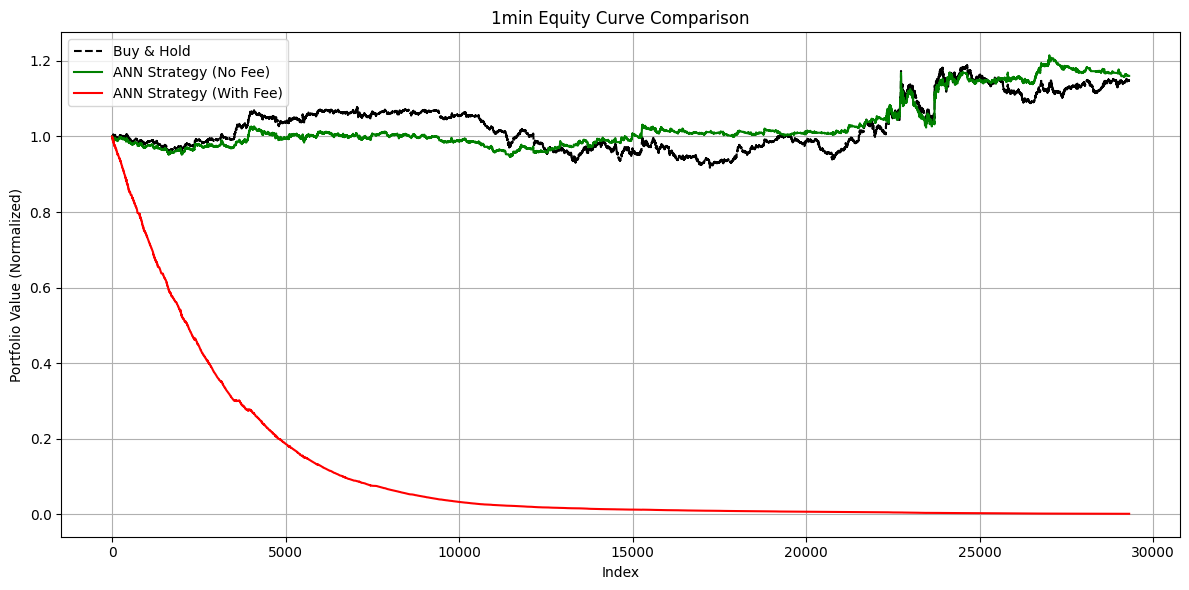

In [38]:
import numpy as np

fee_per_trade = 0.0004 
# Make a copy to avoid modifying the original df_test
returns_strategy = np.where(df_test['Predicted'] == 1, df_test['Return'], 0)
returns_strategy_with_fee = np.where(df_test['Predicted'] == 1, df_test['Return'] - fee_per_trade, 0)

# Buy & Hold (every return in the test set)
buy_hold_equity = (1 + df_test['Return']).cumprod()

# ANN Strategy (No Fee): compound only the predicted trades, else flat (i.e., +0)
strategy_equity_no_fee = (1 + returns_strategy).cumprod()

# ANN Strategy (With Fee): same logic, but subtract fee per trade
strategy_equity_with_fee = (1 + returns_strategy_with_fee).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, buy_hold_equity, label='Buy & Hold', linestyle='--', color='black')
plt.plot(df_test.index, strategy_equity_no_fee, label='ANN Strategy (No Fee)', color='green')
plt.plot(df_test.index, strategy_equity_with_fee, label='ANN Strategy (With Fee)', color='red')
plt.title('1min Equity Curve Comparison')
plt.xlabel('Date' if isinstance(df_test.index[0], pd.Timestamp) else 'Index')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Confusion Matrix:


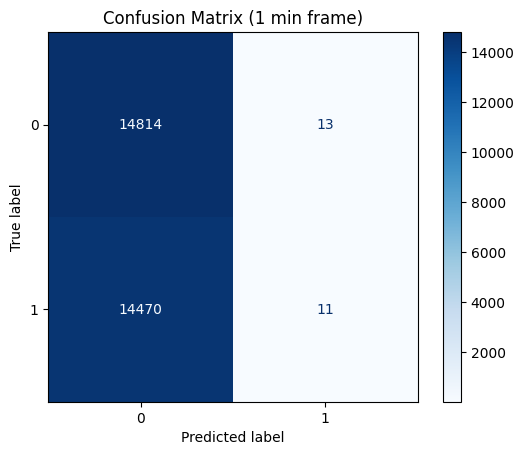


Classification Report:
              precision    recall  f1-score   support

           0       0.51      1.00      0.67     14827
           1       0.46      0.00      0.00     14481

    accuracy                           0.51     29308
   macro avg       0.48      0.50      0.34     29308
weighted avg       0.48      0.51      0.34     29308



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# y_test: true labels, y_pred: predicted labels
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (1 min frame)")
plt.show()

# Optional: Show a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
